<div style="
  background: linear-gradient(135deg, #a8edea, #fed6e3);
  padding: 28px;
  border-radius: 24px;
  text-align: center;
  color: #1a1a2e;
  box-shadow: 0 8px 20px rgba(0,0,0,0.12);
  margin-bottom: 20px;
">
  <h1 style="font-size: 42px; margin-bottom: 8px;">🔬 Blood Cell AI Lab 🩸</h1>
  <h2 style="font-size: 24px; margin-top: 0;">Classifying Cancer Cells with Deep Learning</h2>
  <p style="font-size: 18px; line-height: 1.7;">
    Welcome, future AI researcher! In this project, you will build and compare two deep learning models —
    a <strong>Fully Connected Neural Network (MLP)</strong> and a <strong>Convolutional Neural Network (CNN)</strong> —
    to classify blood cell images for cancer detection.
  </p>
</div>

### Imports

In [14]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, datasets
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 9248
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Define Transforms

In [15]:
from torchvision.models import VGG16_Weights

# Get ImageNet normalization constants from torchvision
imagenet_weights = VGG16_Weights.IMAGENET1K_V1
IMAGENET_MEAN = imagenet_weights.transforms().mean
IMAGENET_STD = imagenet_weights.transforms().std

# Transform for training data (with augmentation)
# Data augmentation (random flip, random rotation) helps the model generalize by exposing it to varied versions of the same image, reducing overfitting.
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),       # Randomly flip images horizontally
    transforms.RandomRotation(15),           # Randomly rotate images up to ±15°
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Transform for test data (no augmentation)
# We must NOT augment test data because we want to evaluate the model on the original, unmodified images — augmentation would make results unreliable.
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print(f"ImageNet mean: {IMAGENET_MEAN}")
print(f"ImageNet std:  {IMAGENET_STD}")
print("Transforms defined successfully.")

ImageNet mean: [0.485, 0.456, 0.406]
ImageNet std:  [0.229, 0.224, 0.225]
Transforms defined successfully.


<span style="color: #e74c3c; font-size: 28px;"><strong>Why these normalization values?</strong></span>

The mean `[0.485, 0.456, 0.406]` and standard deviation `[0.229, 0.224, 0.225]` are the pre-computed channel-wise statistics of the **ImageNet** dataset (over 1 million images, 3 RGB channels). We import them directly from `torchvision.models.VGG16_Weights` to avoid magic numbers.

**Why 3 values instead of 1?** Each color channel (Red, Green, Blue) has its own distribution. For example, the Red channel has a mean of 0.485 while Blue has 0.406 — they are not identical. Normalizing each channel independently with its own mean and std ensures proper scaling per channel, which is critical for the model to learn meaningful patterns from all three color components equally.

### Load Dataset with ImageFolder

In [16]:
DATASET_DIR = "dataset"

# Load dataset twice with different transforms:
# - full_dataset_train: applies augmentation (flip, rotation) for training
# - full_dataset_test: no augmentation, only resize + normalize for evaluation
full_dataset_train = datasets.ImageFolder(root=DATASET_DIR, transform=train_transform)
full_dataset_test = datasets.ImageFolder(root=DATASET_DIR, transform=test_transform)

total_size = len(full_dataset_train)
train_size = int(0.8 * total_size)
test_size = total_size - train_size

# Same seed ensures both splits select the same images
generator = torch.Generator().manual_seed(SEED)
train_dataset, _ = random_split(full_dataset_train, [train_size, test_size], generator=generator)

generator = torch.Generator().manual_seed(SEED)
_, test_dataset = random_split(full_dataset_test, [train_size, test_size], generator=generator)

class_names = full_dataset_train.classes
print(f"Total images: {total_size}")
print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")
print(f"Classes: {class_names}")

Total images: 5000
Train: 4000 | Test: 1000
Classes: ['basophil', 'erythroblast', 'monocyte', 'myeloblast', 'seg_neutrophil']


### Create DataLoaders

In [17]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Verify a batch
sample_batch, sample_labels = next(iter(train_loader))
print(f"Batch shape: {sample_batch.shape}")
print(f"Labels shape: {sample_labels.shape}")
print(f"Pixel range: [{sample_batch.min():.2f}, {sample_batch.max():.2f}]")

Batch shape: torch.Size([32, 3, 64, 64])
Labels shape: torch.Size([32])
Pixel range: [-2.12, 2.64]


### Visualize Sample Images

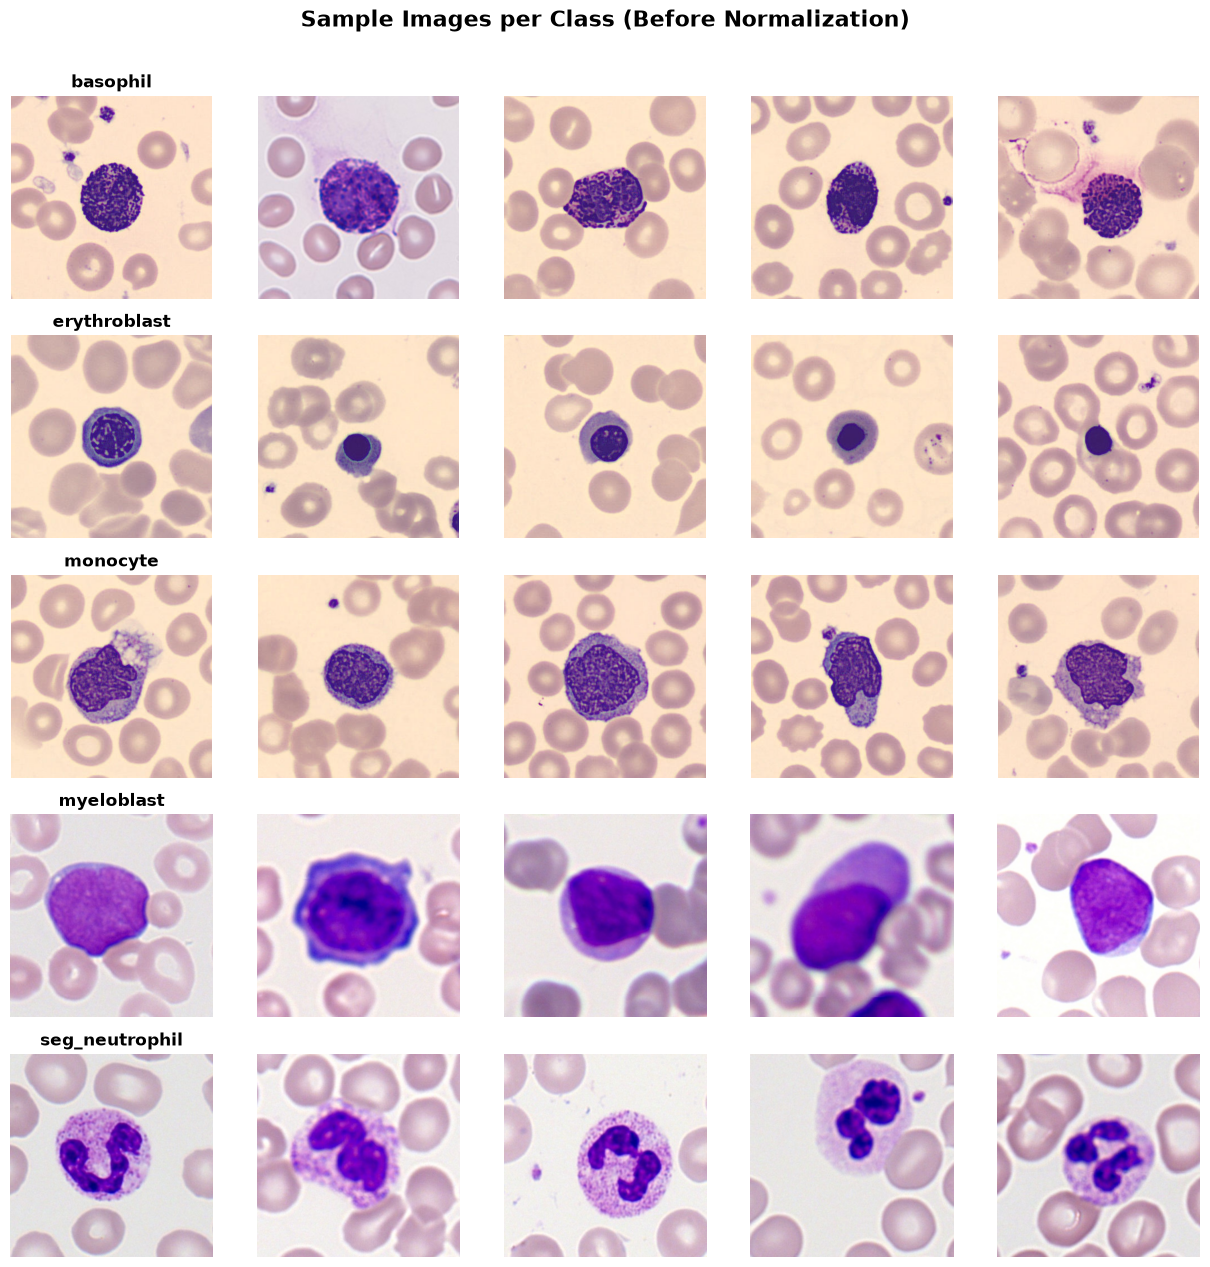

In [18]:
# Load dataset WITHOUT transforms to show original images
viz_dataset = datasets.ImageFolder(root=DATASET_DIR)

# Reshape constants for denormalization (C, 1, 1) for broadcasting
mean_tensor = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std_tensor = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def show_samples_per_class(dataset, class_names, samples_per_class=5):
    """Display random samples from each class (before normalization)."""
    fig, axes = plt.subplots(len(class_names), samples_per_class, figsize=(samples_per_class * 2.5, len(class_names) * 2.5))

    for class_idx, class_name in enumerate(class_names):
        # Get indices for this class
        class_indices = [i for i, (_, label) in enumerate(dataset.samples) if label == class_idx]
        chosen = random.sample(class_indices, min(samples_per_class, len(class_indices)))

        for j, idx in enumerate(chosen):
            img, _ = dataset[idx]
            # img is a PIL Image
            axes[class_idx][j].imshow(img)
            axes[class_idx][j].axis('off')
            if j == 0:
                axes[class_idx][j].set_title(class_name, fontsize=12, fontweight='bold')
        # Remove unused subplots
        for j in range(len(chosen), samples_per_class):
            axes[class_idx][j].axis('off')

    plt.suptitle("Sample Images per Class (Before Normalization)", fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

show_samples_per_class(viz_dataset, class_names)